# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story. Write down a possible Who, What, and How for your data, using the ideas in the book.

**Who:** Studio executives and film distribution strategists who decide how much budget to put behind a film's domestic vs. international release. They have the power to shift marketing spend across regions.

**What:** I want them to *understand* that the share of revenue coming from foreign markets has grown over the 2000-2024 period, and to *believe* that international audiences are now a major driver of blockbuster revenue. The action I want is for them to allocate more marketing budget toward foreign markets.

**How:** I'll show this with the box office data - specifically the trend in average `Foreign %` over time, and the gap between `$Worldwide` and `$Domestic`. A single line chart of foreign revenue share by year tells the story cleanly, with the most recent years emphasized.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

## Load the data
Dataset: Movies Box Office 2000-2024 (Kaggle). 5,000 films with worldwide/domestic/foreign gross, year, genres, rating, vote count, language, and production countries.

In [2]:
df = pd.read_csv('enhanced_box_office_data_2000-2024_u.csv')
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


## Summarize with info() and describe()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  5000 non-null   int64  
 1   Release Group         5000 non-null   str    
 2   $Worldwide            5000 non-null   float64
 3   $Domestic             5000 non-null   float64
 4   Domestic %            5000 non-null   float64
 5   $Foreign              5000 non-null   float64
 6   Foreign %             5000 non-null   float64
 7   Year                  5000 non-null   int64  
 8   Genres                4822 non-null   str    
 9   Rating                4830 non-null   str    
 10  Vote_Count            4830 non-null   float64
 11  Original_Language     4830 non-null   str    
 12  Production_Countries  4800 non-null   str    
dtypes: float64(6), int64(2), str(5)
memory usage: 507.9 KB


In [4]:
df.describe(include='all')

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
count,5000.00000,5000,5.000000e+03,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,4822,4830,4830.000000,4830,4800
unique,NaN,4955,NaN,NaN,NaN,NaN,NaN,NaN,1317,1829,NaN,35,510
top,NaN,Hero,NaN,NaN,NaN,NaN,NaN,NaN,Comedy,6.5/10,NaN,en,United States of America
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,286,102,NaN,3271,1964
mean,100.50000,NaN,1.192137e+08,4.472523e+07,35.740620,7.448809e+07,64.256640,2012.000000,NaN,NaN,2531.585921,NaN,NaN
std,57.74008,NaN,2.005243e+08,7.727026e+07,30.656992,1.334932e+08,30.654531,7.211824,NaN,NaN,3946.272827,NaN,NaN
min,1.00000,NaN,1.666028e+06,0.000000e+00,0.000000,0.000000e+00,0.000000,2000.000000,NaN,NaN,0.000000,NaN,NaN
25%,50.75000,NaN,2.466220e+07,9.275150e+04,0.200000,1.371034e+07,42.200000,2006.000000,NaN,NaN,205.250000,NaN,NaN
50%,100.50000,NaN,4.844658e+07,1.798421e+07,37.050000,3.019444e+07,62.950000,2012.000000,NaN,NaN,1035.500000,NaN,NaN
75%,150.25000,NaN,1.197588e+08,5.386847e+07,57.800000,7.211578e+07,99.800000,2018.000000,NaN,NaN,3065.000000,NaN,NaN


## Duplicate rows

In [5]:
print('Fully duplicate rows:', df.duplicated().sum())

Fully duplicate rows: 0


There are **0 fully duplicate rows**, so no identical records to drop.

## Duplicate values in a column where that is inappropriate
`Release Group` (the film title) should normally be close to unique. Let's check.

In [6]:
dup_titles = df['Release Group'].duplicated().sum()
print('Duplicate Release Group values:', dup_titles)
df[df['Release Group'].duplicated(keep=False)].sort_values('Release Group')[
    ['Release Group','Year','$Worldwide']].head(10)

Duplicate Release Group values: 45


,Release Group,Year,$Worldwide
2547,Bait,2012,3.281341e+07
127,Bait,2000,1.547197e+07
4511,Beast,2022,1.891196e+07
4458,Beast,2022,5.909581e+07
2932,Beauty and the Beast,2014,4.743062e+07
3401,Beauty and the Beast,2017,1.263521e+09
3188,Bride Wars,2015,2.767000e+07
1850,Bride Wars,2009,1.153758e+08
658,Calendar Girls,2003,9.340076e+07
4489,Calendar Girls,2022,2.543362e+07


There are **45 duplicate titles**. These are *not* errors to delete - they're remakes/re-releases or distinct films sharing a name across different `Year` values (e.g. a 2003 film and a 2019 remake). The combination of `Release Group` + `Year` is the real identifier, so I keep them.

## Mean, median, and mode of each column

In [7]:
# Rating is stored as a string like '8.217/10' -> convert to numeric first
df['Rating_num'] = df['Rating'].str.split('/').str[0].astype(float)

numeric_cols = ['$Worldwide','$Domestic','Domestic %','$Foreign','Foreign %',
                'Year','Vote_Count','Rating_num']

summary = pd.DataFrame({
    'mean':   df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
})
summary

,mean,median
$Worldwide,1.192137e+08,48446575.00
$Domestic,4.472523e+07,17984212.00
Domestic %,3.574062e+01,37.05
$Foreign,7.448809e+07,30194438.00
Foreign %,6.425664e+01,62.95
Year,2.012000e+03,2012.00
Vote_Count,2.531586e+03,1035.50
Rating_num,6.510418e+00,6.60


In [8]:
# Mode for categorical columns
for c in ['Genres','Original_Language','Production_Countries']:
    print(f'{c:>22}: {df[c].mode()[0]}')

                Genres: Comedy
     Original_Language: en
  Production_Countries: United States of America


## Missing / null values

In [9]:
nulls = df.isnull().sum()
print(nulls[nulls > 0])

Genres                  178
Rating                  170
Vote_Count              170
Original_Language       170
Production_Countries    200
Rating_num              170
dtype: int64


Five columns have missing values (roughly 170-200 rows each, about 3-4% of the data): `Genres`, `Rating`, `Vote_Count`, `Original_Language`, `Production_Countries`. The four financial columns and `Year` are complete.

**My decisions:**
- **`Rating_num`** (numeric, used in analysis) -> fill with the **median** (6.6). Median is safer than mean here because rating has a few `0.0` outliers that drag the mean down.
- **`Vote_Count`** -> fill with **median** for the same reason (heavily right-skewed).
- **`Genres`, `Original_Language`, `Production_Countries`** (categorical) -> fill with the literal value **'Unknown'** rather than the mode. Imputing the mode (`en`, `Comedy`, `United States`) would invent information and distort class balance.

I do **not** drop these rows - the financial data in them is intact and useful.

In [10]:
# Fill numeric with median
df['Rating_num'] = df['Rating_num'].fillna(df['Rating_num'].median())
df['Vote_Count'] = df['Vote_Count'].fillna(df['Vote_Count'].median())

# Fill categorical with 'Unknown'
for c in ['Genres','Original_Language','Production_Countries']:
    df[c] = df[c].fillna('Unknown')

print('Remaining nulls:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('(Rating string col still has nulls; we use Rating_num going forward.)')

Remaining nulls:
Rating    170
dtype: int64
(Rating string col still has nulls; we use Rating_num going forward.)


## Other inconsistent data
Checking for logical impossibilities (the "action before they were born" analogue for box office data).

In [11]:
# 1) Percentages should sum to ~100 and stay within 0-100
pct_sum = (df['Domestic %'] + df['Foreign %'])
print('Rows where Domestic% + Foreign% not within 99-101:', ((pct_sum < 99) | (pct_sum > 101)).sum())

# 2) Domestic + Foreign should roughly equal Worldwide
calc_ww = df['$Domestic'] + df['$Foreign']
mismatch = (abs(calc_ww - df['$Worldwide']) / df['$Worldwide'] > 0.02).sum()
print('Rows where Domestic+Foreign differs from Worldwide by >2%:', mismatch)

# 3) Years must be within 2000-2024
print('Years outside 2000-2024:', ((df['Year'] < 2000) | (df['Year'] > 2024)).sum())

# 4) Negative money or ratings outside 0-10
print('Negative $Worldwide:', (df['$Worldwide'] < 0).sum())
print('Rating_num outside 0-10:', ((df['Rating_num'] < 0) | (df['Rating_num'] > 10)).sum())

# 5) Zero ratings (suspicious - likely missing data coded as 0)
print('Rating_num exactly 0:', (df['Rating_num'] == 0).sum())

Rows where Domestic% + Foreign% not within 99-101: 3
Rows where Domestic+Foreign differs from Worldwide by >2%: 1
Years outside 2000-2024: 0
Negative $Worldwide: 0
Rating_num outside 0-10: 0
Rating_num exactly 0: 23


The financial logic is internally consistent - percentages sum to ~100, domestic + foreign reconciles to worldwide, and years are all in range. The one quirk is a handful of films with `Rating_num == 0`, which almost certainly means *no rating recorded* rather than a literal zero. For a real analysis I'd treat those as missing too, but they're a small number.

## Encode categorical variables
`Original_Language` is a clean low-cardinality candidate for one-hot encoding. `Genres` is multi-valued (comma-separated) so it needs multi-hot encoding rather than plain one-hot.

In [12]:
# One-hot encode the top languages (keep cardinality manageable)
top_langs = df['Original_Language'].value_counts().head(6).index
lang_ohe = pd.get_dummies(
    df['Original_Language'].where(df['Original_Language'].isin(top_langs), 'other'),
    prefix='lang'
)
lang_ohe.head()

,lang_Unknown,lang_en,lang_fr,lang_ja,lang_ko,lang_other,lang_zh
0,False,True,False,False,False,False,False
1,False,True,False,False,False,False,False
2,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False
4,False,True,False,False,False,False,False


In [13]:
# Multi-hot encode genres (a film can belong to several)
genre_dummies = df['Genres'].str.get_dummies(sep=', ')
print('Genre columns created:', list(genre_dummies.columns))
genre_dummies.head()

Genre columns created: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'Unknown', 'War', 'Western']


,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,Unknown,War,Western
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


## Conclusions

**Are the data usable?** Yes. The dataset is clean, internally consistent, and the financial core (worldwide/domestic/foreign gross, year) has no missing values. The ~3-4% missingness in the metadata columns is easily handled.

**Do I need to modify or correct the data?**
- Converted `Rating` from the string `'8.2/10'` to a numeric `Rating_num`.
- Imputed missing numeric values with the median and missing categoricals with `'Unknown'`.
- Treated the 45 duplicate titles as legitimate (distinct by `Year`), not errors.
- Flagged `Rating_num == 0` as likely-missing for any rating-based analysis.

**Is there class imbalance?** Yes, strongly:
- **Language:** English dominates (~3,271 of ~4,830 non-null rows, roughly 68%), with Japanese, Chinese, French, and Korean trailing far behind. Any model predicting on language would be heavily biased toward English films.
- **Production country** is similarly skewed toward the United States.

This imbalance is worth keeping in mind - it means English/US films set the baseline, and conclusions about "movies in general" really describe Hollywood. If I were modeling, I'd consider stratifying or grouping rare categories into an `other` bucket (as I did in the encoding step).

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

I'm roughly recreating the **line chart** style from the Introduction of *Storytelling With Data* (the kind Knaflic uses to show a trend over time, with the most recent / important point highlighted in a single accent color while the rest is muted grey - her core "declutter and direct attention" technique). I applied that styling to my own data: **average foreign revenue share by year**, tying back to the Who/What/How story above.

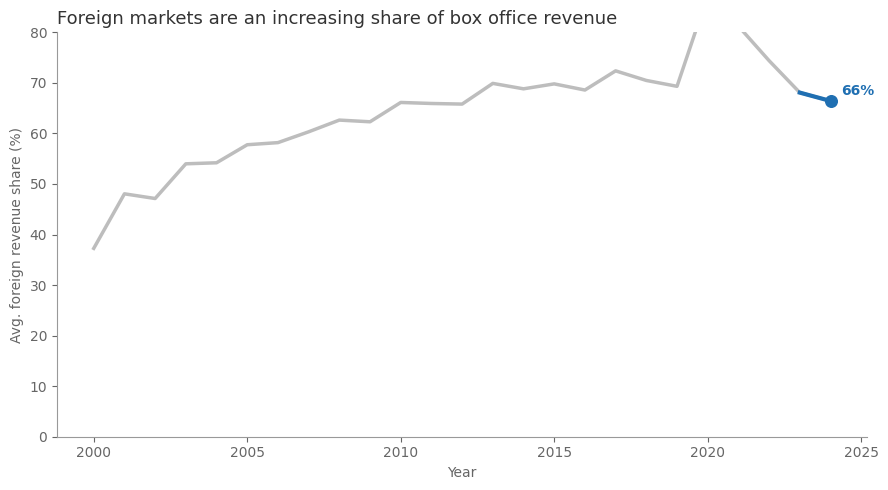

In [14]:
import matplotlib.pyplot as plt

yearly = df.groupby('Year')['Foreign %'].mean()

fig, ax = plt.subplots(figsize=(9, 5))

# Muted grey line for the full trend (Knaflic's 'declutter' approach)
ax.plot(yearly.index, yearly.values, color='#bdbdbd', linewidth=2.5, zorder=1)

# Highlight the most recent year in a single accent color to direct attention
last_x, last_y = yearly.index[-1], yearly.values[-1]
ax.plot(yearly.index[-2:], yearly.values[-2:], color='#1f6fb2', linewidth=3, zorder=2)
ax.scatter([last_x], [last_y], color='#1f6fb2', s=70, zorder=3)
ax.annotate(f'{last_y:.0f}%', (last_x, last_y),
            textcoords='offset points', xytext=(8, 4),
            color='#1f6fb2', fontweight='bold')

# Strip chartjunk: remove top/right spines, lighten the rest
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
for s in ['left', 'bottom']:
    ax.spines[s].set_color('#999999')
ax.tick_params(colors='#666666')

ax.set_title('Foreign markets are an increasing share of box office revenue',
             loc='left', fontsize=13, color='#333333')
ax.set_ylabel('Avg. foreign revenue share (%)', color='#666666')
ax.set_xlabel('Year', color='#666666')
ax.set_ylim(0, 80)

plt.tight_layout()
plt.show()

**What I did / searched:** I looked up how Knaflic styles charts (`matplotlib remove spines`, `ax.spines[...].set_visible(False)`, `ax.annotate offset points`) to reproduce her signature look - grey out everything that isn't the point, use one accent color to direct the eye, put a sentence-style takeaway as the title, and label the data point directly instead of relying on a busy y-axis. The rough shape (an upward trend in foreign share with the latest year emphasized) matches the trend-line examples in the Introduction.